In [ ]:
import os
import pandas as pd

ROOT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/D4_DHU"

records = []

# Loop over disease folders
for disease in ["AMD", "DME", "NORMAL"]:
    disease_path = os.path.join(ROOT_DIR)

    # Find folders like AMD1, AMD2, DME3, NORMAL5, etc.
    for folder in os.listdir(disease_path):
        if not folder.startswith(disease):
            continue

        patient_id = folder  # e.g., AMD1
        tif_dir = os.path.join(
            disease_path,
            folder,
            "TIFFs",
            "8bitTIFFs"
        )

        if not os.path.isdir(tif_dir):
            print(f"Skipping missing: {tif_dir}")
            continue

        # Loop through all tif slices
        for fname in sorted(os.listdir(tif_dir)):
            if fname.lower().endswith(".tif"):
                full_path = os.path.join(tif_dir, fname)

                records.append({
                    "patient_id": patient_id,
                    "label": disease,
                    "new_file_path": full_path
                })

# Create DataFrame
df = pd.DataFrame(records)

# Save
csv_path = "dhu.csv"

print("Done!")
print("Total slices:", len(df))
print(df.head())


Done!
Total slices: 3231
  patient_id label                                      new_file_path
0       AMD3   AMD  /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...
1       AMD3   AMD  /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...
2       AMD3   AMD  /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...
3       AMD3   AMD  /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...
4       AMD3   AMD  /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...


In [ ]:
# Multi-class label
df["three_class_label"] = df["label"].map({
    "NORMAL": 0,
    "DME": 1,
    "AMD": 2
})

# Binary label (NORMAL = 0, DME + AMD = 1)
df["binary_label"] = df["label"].map({
    "NORMAL": 0,
    "DME": 1,
    "AMD": 1
})
df.head()

In [ ]:
# df.to_csv(csv_path, index=False)


/home/bharath/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


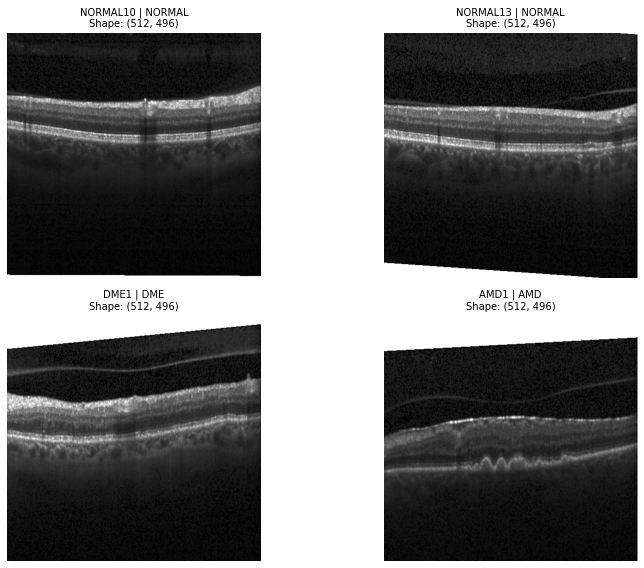

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load CSV
df = pd.read_csv("dhu.csv")

# Randomly sample 4 rows
sample_df = df.sample(n=4)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.new_file_path).convert("L")

    plt.subplot(2, 2, i)
    plt.imshow(img, cmap="gray")
    plt.title(
        f"{row.patient_id} | {row.label}\nShape: {img.size}",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
from PIL import Image
from tqdm import tqdm

# ===============================
# CONFIG
# ===============================
CSV_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/dhu.csv"

# ===============================
# LOAD CSV
# ===============================
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows")

# ===============================
# FUNCTION TO GET SHAPE
# ===============================
def get_image_shape(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            return f"{h}x{w}"   # HxW (correct)
    except Exception:
        return "READ_ERROR"

# ===============================
# APPLY
# ===============================
tqdm.pandas(desc="Reading DHU images")
df["image_shape"] = df["new_file_path"].progress_apply(get_image_shape)

# ===============================
# SAVE BACK TO SAME FILE
# ===============================

# df.to_csv(CSV_PATH, index=False)
print("✅ CSV updated successfully")

# ===============================
# DISTRIBUTION
# ===============================
shape_counts = df["image_shape"].value_counts()
shape_percent = (shape_counts / len(df)) * 100

print("\n🔹 Unique image shapes:", len(shape_counts))
print("\n🔹 Shape distribution:\n")

for shape, count in shape_counts.items():
    print(f"{shape:12s} : {count:6d} images ({shape_percent[shape]:.2f}%)")


Loaded 3231 rows


Reading DHU images: 100%|██████████| 3231/3231 [00:09<00:00, 352.34it/s]

✅ CSV updated successfully

🔹 Unique image shapes: 3

🔹 Shape distribution:

496x512      :   2346 images (72.61%)
496x768      :    519 images (16.06%)
496x1024     :    366 images (11.33%)


In [13]:
import pandas as pd

# ===============================
# PATHS
# ===============================
INPUT_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/dhu.csv"
OUTPUT_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/dhu_filtered.csv"

# ===============================
# LOAD
# ===============================
df = pd.read_csv(INPUT_CSV)

print("Original count:", len(df))
print("\nOriginal shape distribution:")
print(df["image_shape"].value_counts())

# ===============================
# FILTER OUT 496x1024
# ===============================
df_filtered = df[df["image_shape"] != "496x1024"].reset_index(drop=True)

# ===============================
# SAVE
# ===============================
df_filtered.to_csv(OUTPUT_CSV, index=False)

# ===============================
# STATS
# ===============================
print("\nAfter filtering:")
print("Remaining rows:", len(df_filtered))
print("\nNew shape distribution:")
print(df_filtered["image_shape"].value_counts())


Original count: 3231

Original shape distribution:
image_shape
496x512     2346
496x768      519
496x1024     366
Name: count, dtype: int64

After filtering:
Remaining rows: 2865

New shape distribution:
image_shape
496x512    2346
496x768     519
Name: count, dtype: int64
